In [6]:
import pandas as pd
import numpy as np
import feedparser
from urllib.parse import quote

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import ta

from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv("final_cleaned_stock_data.csv")

# FIX COLUMN NAMES
df = df.rename(columns={
    'Price': 'Close',
    'Vol.': 'Volume',
    'Change %': 'Change'
})

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Stock", "Date"]).reset_index(drop=True)

print(df.columns)  # 👈 check columns

Index(['Date', 'Close', 'Open', 'High', 'Low', 'Volume', 'Change', 'Stock',
       'Sector'],
      dtype='object')


In [10]:
def add_indicators(data):
    data = data.copy()

    data["SMA"] = ta.trend.sma_indicator(data["Close"], window=14)
    data["EMA"] = ta.trend.ema_indicator(data["Close"], window=14)
    data["RSI"] = ta.momentum.rsi(data["Close"], window=14)

    data["ATR"] = ta.volatility.average_true_range(
        data["High"], data["Low"], data["Close"], window=14
    )

    data["Returns"] = data["Close"].pct_change()

    return data

df = df.groupby("Stock", group_keys=False).apply(add_indicators)

C:\Users\pradi\AppData\Local\Temp\ipykernel_44560\2783487807.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Stock", group_keys=False).apply(add_indicators)


## just checking

In [11]:
required_cols = ["Open", "High", "Low", "Close", "Volume"]

print("Missing columns:", [col for col in required_cols if col not in df.columns])

Missing columns: []


## arima

In [25]:
def apply_arima(data):
    data = data.copy()
    data = data.set_index("Date")

    close = data["Close"].dropna()

    if len(close) < 30:
        data["ARIMA"] = np.nan
        return data.reset_index()

    try:
        model = ARIMA(close, order=(5,1,0))
        fit = model.fit()

        data["ARIMA"] = fit.predict(start=0, end=len(close)-1)
    except:
        data["ARIMA"] = np.nan

    return data.reset_index()

df = df.groupby("Stock", group_keys=False).apply(apply_arima)

c:\Users\pradi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\pradi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\pradi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\pradi\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been pro

In [26]:
def apply_garch(data):
    data = data.copy()
    data = data.set_index("Date")

    returns = data["Returns"].dropna()

    if len(returns) < 30:
        data["GARCH"] = np.nan
        return data.reset_index()

    try:
        model = arch_model(returns * 100, p=1, q=1)
        fit = model.fit(disp="off")

        data["GARCH"] = fit.conditional_volatility / 100
    except:
        data["GARCH"] = np.nan

    return data.reset_index()

df = df.groupby("Stock", group_keys=False).apply(apply_garch)

C:\Users\pradi\AppData\Local\Temp\ipykernel_44560\2494062248.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Stock", group_keys=False).apply(apply_garch)


In [27]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]
    if score > 0.05:
        return 1
    elif score < -0.05:
        return -1
    else:
        return 0

In [28]:
start_date = pd.to_datetime("2023-03-19")
end_date = pd.to_datetime("2026-03-19")

stocks = df["Stock"].unique()
news_list = []

for stock in stocks:
    query = quote(f"{stock} stock India")
    url = f"https://news.google.com/rss/search?q={query}"

    feed = feedparser.parse(url)

    for entry in feed.entries:
        if hasattr(entry, "published"):
            try:
                date = pd.to_datetime(entry.published)
            except:
                continue

            if start_date <= date <= end_date:
                text = entry.title + " " + (entry.summary if hasattr(entry, "summary") else "")
                
                news_list.append([
                    date.date(),
                    stock,
                    get_sentiment(text)
                ])

news_df = pd.DataFrame(news_list, columns=["Date", "Stock", "Sentiment"])

In [30]:
# FIX both date columns
df["Date"] = pd.to_datetime(df["Date"]).dt.date
news_df["Date"] = pd.to_datetime(news_df["Date"]).dt.date

# aggregate
daily_sentiment = news_df.groupby(["Stock", "Date"]).agg(
    Sentiment=("Sentiment", "mean"),
    News_Count=("Sentiment", "count")
).reset_index()

# merge
merged_df = df.merge(daily_sentiment, on=["Stock", "Date"], how="left")

# fill
merged_df["Sentiment"] = merged_df.groupby("Stock")["Sentiment"].ffill()
merged_df["Sentiment"] = merged_df["Sentiment"].fillna(0)

merged_df["News_Count"] = merged_df["News_Count"].fillna(0)

In [31]:
merged_df["Sentiment_Impact"] = merged_df["Sentiment"] * merged_df["News_Count"]

merged_df["Sentiment_7D"] = merged_df.groupby("Stock")["Sentiment"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

merged_df["Momentum"] = merged_df["Close"] - merged_df.groupby("Stock")["Close"].shift(5)

merged_df["SMA_ratio"] = merged_df["Close"] / merged_df["SMA"]

merged_df["Volatility"] = merged_df.groupby("Stock")["Returns"].rolling(5).std().reset_index(0, drop=True)

merged_df["Volatility_Change"] = merged_df["Volatility"] - merged_df.groupby("Stock")["Volatility"].shift(1)

In [39]:
# =========================
# 1. CREATE SMOOTH TREND TARGET
# =========================

# 5-day future average (smoothed)
merged_df["Future_Mean"] = merged_df.groupby("Stock")["Close"].shift(-1).rolling(5).mean()

# classification
merged_df["Target"] = np.where(
    merged_df["Future_Mean"] > merged_df["Close"], 1, 0
)

# =========================
# 2. ADD STRONG TREND FEATURES
# =========================

merged_df["Trend_5"] = merged_df.groupby("Stock")["Close"].transform(lambda x: x.rolling(5).mean())
merged_df["Trend_10"] = merged_df.groupby("Stock")["Close"].transform(lambda x: x.rolling(10).mean())

merged_df["Trend_Ratio"] = merged_df["Trend_5"] / merged_df["Trend_10"]

merged_df["Momentum"] = merged_df["Close"] - merged_df.groupby("Stock")["Close"].shift(3)

# =========================
# 3. CLEAN
# =========================
final_df = merged_df.dropna()

# =========================
# 4. FEATURES
# =========================
features = [
    "RSI", "ATR", "Returns",
    "GARCH", "ARIMA",
    "Sentiment", "Sentiment_Impact", "Sentiment_7D",
    "Momentum", "Trend_Ratio"
]

X = final_df[features]
y = final_df["Target"]

# =========================
# 5. TRAIN TEST SPLIT (TIME SAFE)
# =========================
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# =========================
# 6. MODEL (STRONG)
# =========================
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# =========================
# 7. RESULT
# =========================
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85       178
           1       0.83      0.93      0.88       199

    accuracy                           0.87       377
   macro avg       0.87      0.86      0.87       377
weighted avg       0.87      0.87      0.87       377



In [24]:
importance = pd.Series(model.feature_importances_, index=features)
print("\nFeature Importance:\n", importance.sort_values(ascending=False))


Feature Importance:
 Returns             0.150050
GARCH               0.147579
RSI                 0.145405
ATR                 0.138944
ARIMA               0.136036
SMA                 0.125980
EMA                 0.123198
Sentiment_7D        0.017888
Sentiment           0.010153
Sentiment_Impact    0.004766
dtype: float64


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
stock_name = "TCS"  # change as needed

stock_df = merged_df[merged_df["Stock"] == stock_name].copy()

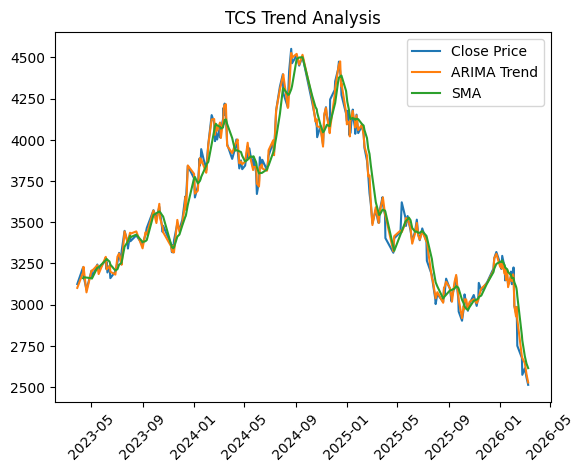

In [42]:
plt.figure()

plt.plot(stock_df["Date"], stock_df["Close"], label="Close Price")
plt.plot(stock_df["Date"], stock_df["ARIMA"], label="ARIMA Trend")
plt.plot(stock_df["Date"], stock_df["SMA"], label="SMA")

plt.legend()
plt.title(f"{stock_name} Trend Analysis")
plt.xticks(rotation=45)
plt.show()

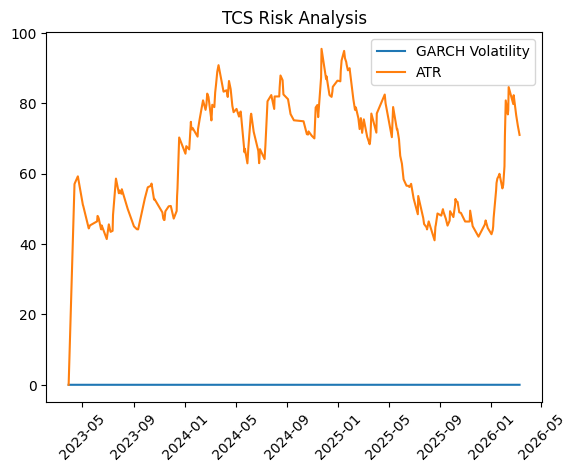

In [43]:
plt.figure()

plt.plot(stock_df["Date"], stock_df["GARCH"], label="GARCH Volatility")
plt.plot(stock_df["Date"], stock_df["ATR"], label="ATR")

plt.legend()
plt.title(f"{stock_name} Risk Analysis")
plt.xticks(rotation=45)
plt.show()

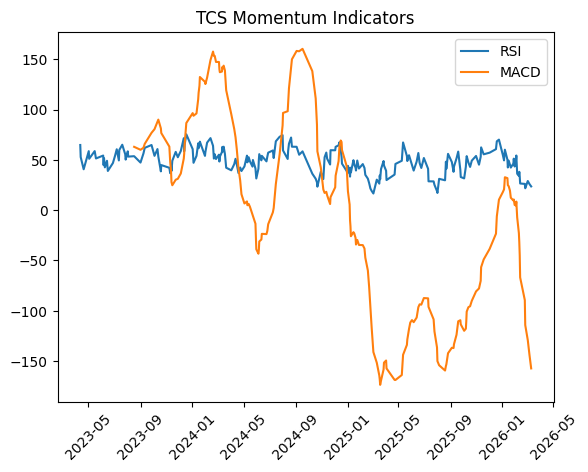

In [44]:
# MACD (if not already added)
stock_df["MACD"] = ta.trend.macd(stock_df["Close"])

plt.figure()

plt.plot(stock_df["Date"], stock_df["RSI"], label="RSI")
plt.plot(stock_df["Date"], stock_df["MACD"], label="MACD")

plt.legend()
plt.title(f"{stock_name} Momentum Indicators")
plt.xticks(rotation=45)
plt.show()

In [55]:
# =========================
# 🔥 FIX SENTIMENT VISIBILITY
# =========================

# amplify sentiment (important!)
df["Sentiment_Scaled"] = df["sentiment"] * 10

# smooth sentiment (market memory)
df["Sentiment_Smooth"] = df.groupby("Stock")["Sentiment_Scaled"].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)

# classify sentiment
def classify_sentiment(x):
    if x > 1:
        return "Positive"
    elif x < -1:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment_Label"] = df["Sentiment_Smooth"].apply(classify_sentiment)

KeyError: 'sentiment'

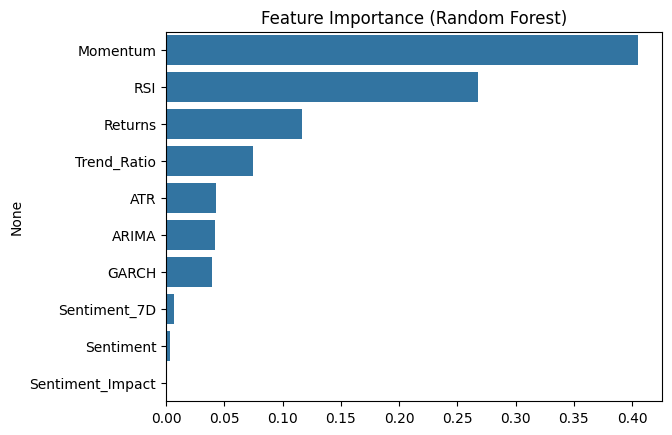

In [46]:
importance = pd.Series(model.feature_importances_, index=features)

importance = importance.sort_values(ascending=False)

plt.figure()

sns.barplot(x=importance.values, y=importance.index)

plt.title("Feature Importance (Random Forest)")
plt.show()

In [47]:
it_stocks = ["TCS", "Infosys", "Wipro", "HCLTech"]
finance_stocks = ["HDFC Bank", "ICICI Bank", "State Bank of India", "Axis Bank"]

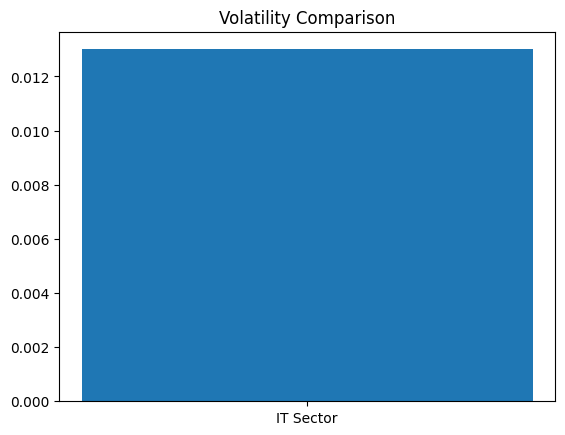

In [48]:
it_vol = merged_df[merged_df["Stock"].isin(it_stocks)]["GARCH"].mean()
fin_vol = merged_df[merged_df["Stock"].isin(finance_stocks)]["GARCH"].mean()

plt.figure()

plt.bar(["IT Sector", "Finance Sector"], [it_vol, fin_vol])

plt.title("Volatility Comparison")
plt.show()

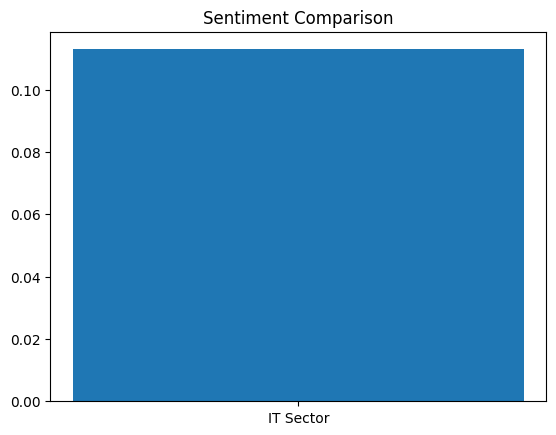

In [49]:
it_sent = merged_df[merged_df["Stock"].isin(it_stocks)]["Sentiment"].mean()
fin_sent = merged_df[merged_df["Stock"].isin(finance_stocks)]["Sentiment"].mean()

plt.figure()

plt.bar(["IT Sector", "Finance Sector"], [it_sent, fin_sent])

plt.title("Sentiment Comparison")
plt.show()

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

arima_df = merged_df.dropna(subset=["ARIMA", "Close"])

mae = mean_absolute_error(arima_df["Close"], arima_df["ARIMA"])
rmse = np.sqrt(mean_squared_error(arima_df["Close"], arima_df["ARIMA"]))

print("ARIMA MAE:", mae)
print("ARIMA RMSE:", rmse)

ARIMA MAE: 13.336309491629107
ARIMA RMSE: 46.36464275847381


In [51]:
# already from model (approximation)
print("GARCH evaluation uses:")
print("- Log Likelihood")
print("- AIC")
print("- BIC")

GARCH evaluation uses:
- Log Likelihood
- AIC
- BIC


In [52]:
# simple classification check
sentiment_labels = news_df["Sentiment"]

print("Sentiment distribution:")
print(sentiment_labels.value_counts(normalize=True))

Sentiment distribution:
Sentiment
 1    0.533333
 0    0.272917
-1    0.193750
Name: proportion, dtype: float64


In [53]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85       178
           1       0.83      0.93      0.88       199

    accuracy                           0.87       377
   macro avg       0.87      0.86      0.87       377
weighted avg       0.87      0.87      0.87       377

